In [1]:
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics  import silhouette_score
import pandas as pd

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df.head(1)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [5]:
df = df.drop("CustomerID", axis=1)
df.columns

Index(['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [11]:
df.groupby("Genre")[ "Spending Score (1-100)"].mean()

Genre
Female    51.526786
Male      48.511364
Name: Spending Score (1-100), dtype: float64

In [13]:
bins = [0, 18, 30, 45, 60, 100]
labels = ["Teen", "Young Adult", "Adult", "Middle Age", "Senior"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

df.groupby("Age_Group", observed=True)["Spending Score (1-100)"].mean()

Age_Group
Teen           60.000000
Young Adult    61.103448
Adult          52.569444
Middle Age     35.102041
Senior         44.176471
Name: Spending Score (1-100), dtype: float64

In [16]:
# we will train the model on Age, income and the score


from sklearn.preprocessing import StandardScaler
df_back = df[["Age", "Annual Income (k$)","Spending Score (1-100)"]]
sc = StandardScaler()

scaled_data = sc.fit_transform(df_back)

scaled_data[0]



array([-1.42456879, -1.73899919, -0.43480148])

In [22]:
model = KMeans(n_clusters=8, init="k-means++",n_init="auto", random_state=42)
model .fit(scaled_data)

,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [25]:
print("Cluster Centres")
print(model.cluster_centers_)
print(len(model.cluster_centers_))

Cluster Centres
[[ 1.29588945 -0.23441355 -0.04839153]
 [-0.42973399  0.68673384  1.241219  ]
 [ 0.36959845  1.12879725 -1.25264236]
 [-1.28103541  0.10180828 -0.36951067]
 [-0.99396865 -1.34734766  1.06404834]
 [ 0.47895722 -1.30822992 -1.19644353]
 [-0.39047603 -0.28335596  0.004588  ]
 [-0.47724849  1.87564575  1.23452563]]
8


In [26]:
print("Inertia")
print(model.inertia_)

Inertia
113.72723000071338


In [33]:
# lets us try for k 1-12 and then we will plot the clusters for them 

inertias = []
k_ranges = range(1,12)
for i in range (1,12):
    model = KMeans(n_clusters=i, init="k-means++",n_init="auto", random_state=42)
    model .fit(scaled_data)
    print(model.inertia_)
    inertias.append(model.inertia_)
    

inertias

599.9999999999999
389.3861889564372
295.4562449213556
205.22514747675913
169.89149793438582
134.35277477401493
121.38935022502872
113.72723000071338
102.13623844329254
92.55027231838785
72.62576763493588


[599.9999999999999,
 389.3861889564372,
 295.4562449213556,
 205.22514747675913,
 169.89149793438582,
 134.35277477401493,
 121.38935022502872,
 113.72723000071338,
 102.13623844329254,
 92.55027231838785,
 72.62576763493588]

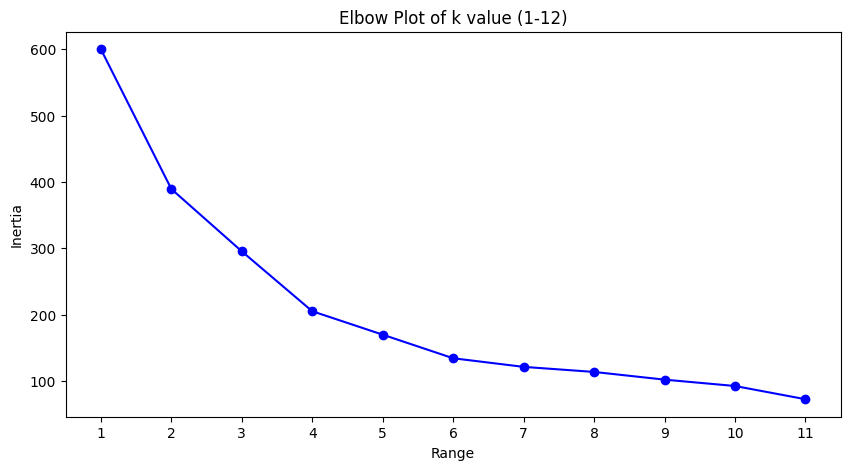

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(k_ranges, inertias, marker = "o", linestyle  = "-" ,color = "b")
plt.title("Elbow Plot of k value (1-12)")
plt.xlabel("Range")
plt.ylabel("Inertia")
plt.xticks(k_ranges)
plt.show()

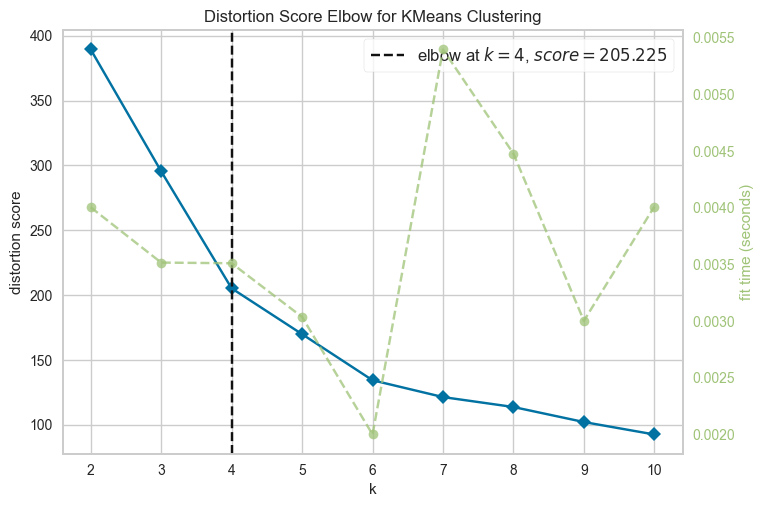

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [36]:
from yellowbrick.cluster import KElbowVisualizer

elbow  = KElbowVisualizer(model,plot = k_ranges)

elbow.fit(scaled_data)
elbow.show()